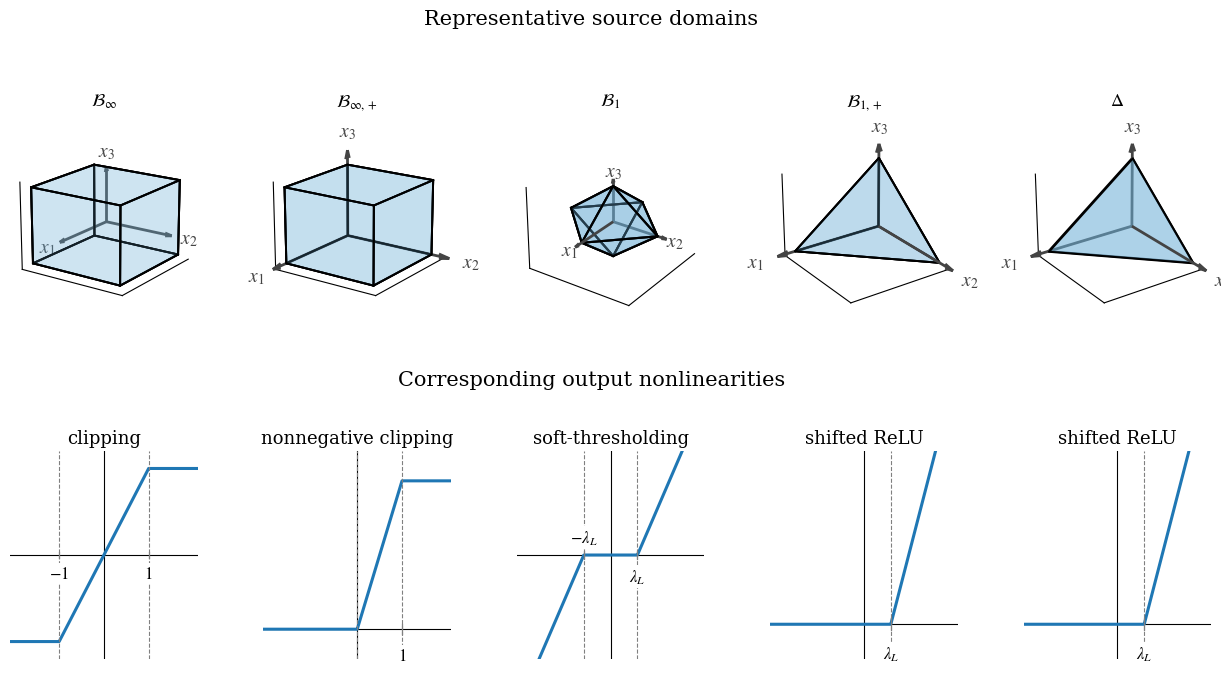

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ------------------------------------------------------------
# Style
# ------------------------------------------------------------
plt.rcParams.update({
    "font.size": 11,
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

POLY_COLOR = "#6baed6"

# ------------------------------------------------------------
# Helpers for 3D plots
# ------------------------------------------------------------
def set_axes_equal(ax):
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])

    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)

    radius = 0.5 * max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - radius, x_middle + radius])
    ax.set_ylim3d([y_middle - radius, y_middle + radius])
    ax.set_zlim3d([z_middle - radius, z_middle + radius])

def clean_3d_axis(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_zlabel("")
    ax.grid(False)
    try:
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False
        ax.xaxis.pane.set_edgecolor("white")
        ax.yaxis.pane.set_edgecolor("white")
        ax.zaxis.pane.set_edgecolor("white")
    except Exception:
        pass

def add_3d_axes(ax, origin=(0, 0, 0), length=1.2, color="#444444", offset=1.15):
    ox, oy, oz = origin
    ax.quiver(ox, oy, oz, length, 0, 0, color=color, linewidth=2.0, arrow_length_ratio=0.10)
    ax.quiver(ox, oy, oz, 0, length, 0, color=color, linewidth=2.0, arrow_length_ratio=0.10)
    ax.quiver(ox, oy, oz, 0, 0, length, color=color, linewidth=2.0, arrow_length_ratio=0.10)
    
    ax.text(ox + length * offset, oy, oz, r"$x_1$", color=color, fontsize=14, ha='center', va='center')
    ax.text(ox, oy + length * offset, oz, r"$x_2$", color=color, fontsize=14, ha='center', va='center')
    ax.text(ox, oy, oz + length * offset, r"$x_3$", color=color, fontsize=14, ha='center', va='center')

def draw_polyhedron(ax, vertices, faces, facecolor=POLY_COLOR, edgecolor="black", alpha=0.22, lw=1.4):
    poly3d = [[vertices[idx] for idx in face] for face in faces]
    coll = Poly3DCollection(
        poly3d,
        facecolors=facecolor,
        edgecolors=edgecolor,
        linewidths=lw,
        alpha=alpha
    )
    ax.add_collection3d(coll)

    drawn = set()
    for face in faces:
        for i in range(len(face)):
            a = face[i]
            b = face[(i + 1) % len(face)]
            edge = tuple(sorted((a, b)))
            if edge not in drawn:
                drawn.add(edge)
                p1 = vertices[a]
                p2 = vertices[b]
                ax.plot(
                    [p1[0], p2[0]],
                    [p1[1], p2[1]],
                    [p1[2], p2[2]],
                    color=edgecolor,
                    lw=lw
                )

def cube_vertices(a=-1.0, b=1.0):
    return np.array([
        [a, a, a], [b, a, a], [b, b, a], [a, b, a],
        [a, a, b], [b, a, b], [b, b, b], [a, b, b]
    ], dtype=float)

def cube_faces():
    return [
        [0, 1, 2, 3], [4, 5, 6, 7],
        [0, 1, 5, 4], [1, 2, 6, 5],
        [2, 3, 7, 6], [3, 0, 4, 7]
    ]

def octahedron_vertices(scale=1.0):
    return scale * np.array([
        [ 1, 0, 0], [-1, 0, 0],
        [ 0, 1, 0], [ 0,-1, 0],
        [ 0, 0, 1], [ 0, 0,-1]
    ], dtype=float)

def octahedron_faces():
    return [
        [0, 2, 4], [2, 1, 4], [1, 3, 4], [3, 0, 4],
        [2, 0, 5], [1, 2, 5], [3, 1, 5], [0, 3, 5]
    ]

def tetrahedron_vertices():
    return np.array([
        [0, 0, 0],
        [1, 0, 0],
        [0, 1, 0],
        [0, 0, 1]
    ], dtype=float)

def tetrahedron_faces():
    return [
        [0, 1, 2],
        [0, 1, 3],
        [0, 2, 3],
        [1, 2, 3]
    ]

def simplex_vertices():
    return np.array([
        [1, 0, 0],
        [0, 1, 0],
        [0, 0, 1]
    ], dtype=float)

# ------------------------------------------------------------
# Helpers for activation plots
# ------------------------------------------------------------
def style_activation_axis(ax, xlim=(-2.2, 2.2), ylim=(-1.25, 1.25)):
    ax.axhline(0, color="black", lw=0.8)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

def mark_x_label(ax, x0, label, y_text=-0.12, tick_h=0.035, color="gray", va="top"):
    ax.plot([x0, x0], [-tick_h, tick_h], color=color, lw=0.9)
    ax.text(x0, y_text, label, ha="center", va=va, fontsize=12,
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5))

# ------------------------------------------------------------
# Build figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(15.5, 7.6))
gs = fig.add_gridspec(
    2, 5,
    height_ratios=[1.45, 1.0],
    hspace=0.30,
    wspace=0.35
)

# ---------------------------
# Top row: source domains
# ---------------------------

# 1) B_infty : cube [-1,1]^3 (Antisparse)
ax = fig.add_subplot(gs[0, 0], projection="3d")
V = cube_vertices(-1, 1)
draw_polyhedron(ax, V, cube_faces(), facecolor=POLY_COLOR, alpha=0.18)
add_3d_axes(ax, origin=(0, 0, 0), length=1.45, offset=1.25)
ax.view_init(elev=18, azim=35)
ax.set_title(r"$\mathcal{B}_\infty$", pad=18)
set_axes_equal(ax)
clean_3d_axis(ax)

# 2) B_{infty,+} : cube [0,1]^3
ax = fig.add_subplot(gs[0, 1], projection="3d")
V = cube_vertices(0, 1)
draw_polyhedron(ax, V, cube_faces(), facecolor=POLY_COLOR, alpha=0.22)
add_3d_axes(ax, origin=(0, 0, 0), length=1.2, offset=1.2)
ax.view_init(elev=18, azim=35)
ax.set_title(r"$\mathcal{B}_{\infty,+}$", pad=18)
set_axes_equal(ax)
clean_3d_axis(ax)

# 3) B_1 : octahedron (Sparse)
ax = fig.add_subplot(gs[0, 2], projection="3d")
V = octahedron_vertices(scale=1.75) 
draw_polyhedron(ax, V, octahedron_faces(), facecolor=POLY_COLOR, alpha=0.35, lw=1.5)
add_3d_axes(ax, origin=(0, 0, 0), length=2.1, offset=1.15) 
ax.view_init(elev=28, azim=35) 
ax.set_title(r"$\mathcal{B}_1$", pad=18)
set_axes_equal(ax)
clean_3d_axis(ax)

# 4) B_{1,+} : tetrahedron conv{0,e1,e2,e3}
ax = fig.add_subplot(gs[0, 3], projection="3d")
V = tetrahedron_vertices()
# Kept alpha relatively low to show it is a filled volume
draw_polyhedron(ax, V, tetrahedron_faces(), facecolor=POLY_COLOR, alpha=0.25)
add_3d_axes(ax, origin=(0, 0, 0), length=1.2, offset=1.2)
# Adjusted viewing angle to better show the "corner" connecting to the origin
ax.view_init(elev=25, azim=55)
ax.set_title(r"$\mathcal{B}_{1,+}$", pad=18)
set_axes_equal(ax)
clean_3d_axis(ax)

# 5) Delta : standard simplex face conv{e1,e2,e3}
ax = fig.add_subplot(gs[0, 4], projection="3d")
V = simplex_vertices()
# Increased alpha to 0.55 to make the simplex look like a solid floating plane
tri = Poly3DCollection([[V[0], V[1], V[2]]],
                       facecolors=POLY_COLOR,
                       edgecolors="black",
                       linewidths=1.5,
                       alpha=0.55)
ax.add_collection3d(tri)
for i in range(3):
    p1 = V[i]
    p2 = V[(i + 1) % 3]
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color="black", lw=1.5)

# Added dashed scaffolding to explicitly show the hollow space underneath
ax.plot([0, 1], [0, 0], [0, 0], color="gray", ls="--", lw=1.2, alpha=0.8)
ax.plot([0, 0], [0, 1], [0, 0], color="gray", ls="--", lw=1.2, alpha=0.8)
ax.plot([0, 0], [0, 0], [0, 1], color="gray", ls="--", lw=1.2, alpha=0.8)

add_3d_axes(ax, origin=(0, 0, 0), length=1.2, offset=1.2)
# Matched the viewing angle of B_1,+ so they can be perfectly compared
ax.view_init(elev=25, azim=55)
ax.set_title(r"$\Delta$", pad=18)
set_axes_equal(ax)
clean_3d_axis(ax)

# ---------------------------
# Bottom row: activations
# ---------------------------
x = np.linspace(-2.2, 2.2, 1000)
lam = 0.6

# 1) clipping [-1,1]
ax = fig.add_subplot(gs[1, 0])
y = np.clip(x, -1, 1)
style_activation_axis(ax, xlim=(-2.1, 2.1), ylim=(-1.2, 1.2))
ax.plot(x, y, lw=2.2)
ax.axvline(-1, color="gray", ls="--", lw=0.8)
ax.axvline(1, color="gray", ls="--", lw=0.8)
mark_x_label(ax, -1, r"$-1$")
mark_x_label(ax, 1, r"$1$")
ax.set_title(r"clipping")

# 2) clipping [0,1]
ax = fig.add_subplot(gs[1, 1])
y = np.clip(x, 0, 1)
style_activation_axis(ax, xlim=(-2.1, 2.1), ylim=(-0.2, 1.2))
ax.plot(x, y, lw=2.2)
ax.axvline(0, color="gray", ls="--", lw=0.8)
ax.axvline(1, color="gray", ls="--", lw=0.8)
mark_x_label(ax, 1, r"$1$", y_text=-0.12)
ax.set_title(r"nonnegative clipping")

# 3) soft-thresholding
ax = fig.add_subplot(gs[1, 2])
y = np.sign(x) * np.maximum(np.abs(x) - lam, 0.0)
style_activation_axis(ax, xlim=(-2.1, 2.1), ylim=(-1.0, 1.0))
ax.plot(x, y, lw=2.2)
ax.axvline(-lam, color="gray", ls="--", lw=0.8)
ax.axvline(lam, color="gray", ls="--", lw=0.8)
mark_x_label(ax, -lam, r"$-\lambda_L$", y_text=0.08, va="bottom") 
mark_x_label(ax, lam, r"$\lambda_L$", y_text=-0.12)
ax.set_title(r"soft-thresholding")

# 4) shifted ReLU
ax = fig.add_subplot(gs[1, 3])
y = np.maximum(x - lam, 0.0)
style_activation_axis(ax, xlim=(-2.1, 2.1), ylim=(-0.2, 1.0))
ax.plot(x, y, lw=2.2)
ax.axvline(lam, color="gray", ls="--", lw=0.8)
mark_x_label(ax, lam, r"$\lambda_L$", y_text=-0.12)
ax.set_title(r"shifted ReLU")

# 5) shifted ReLU (simplex)
ax = fig.add_subplot(gs[1, 4])
y = np.maximum(x - lam, 0.0)
style_activation_axis(ax, xlim=(-2.1, 2.1), ylim=(-0.2, 1.0))
ax.plot(x, y, lw=2.2)
ax.axvline(lam, color="gray", ls="--", lw=0.8)
mark_x_label(ax, lam, r"$\lambda_L$", y_text=-0.12)
ax.set_title(r"shifted ReLU")

# Row titles
fig.text(0.5, 0.965, "Representative source domains", ha="center", va="top", fontsize=15)
fig.text(0.5, 0.49, "Corresponding output nonlinearities", ha="center", va="top", fontsize=15)

# plt.savefig("Figures/Polytopes_and_Activations.pdf", bbox_inches="tight")
plt.show()